# Домашнє завдання: Прогнозування орендної плати за житло

## Мета завдання
Застосувати знання з лекції для побудови моделі лінійної регресії, що прогнозує орендну плату за житло в Індії. Ви пройдете весь цикл вирішення задачі машинного навчання: від дослідницького аналізу до оцінки якості моделі.

## Опис датасету
**House Rent Prediction Dataset** містить інформацію про 4700+ оголошень про оренду житла в Індії з такими параметрами:
- **BHK**: Кількість спалень, залів, кухонь
- **Rent**: Орендна плата (цільова змінна)
- **Size**: Площа в квадратних футах
- **Floor**: Поверх та загальна кількість поверхів
- **Area Type**: Тип розрахунку площі
- **Area Locality**: Район
- **City**: Місто
- **Furnishing Status**: Стан меблювання
- **Tenant Preferred**: Тип орендаря
- **Bathroom**: Кількість ванних кімнат
- **Point of Contact**: Контактна особа

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `House_Rent_Dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (включно з типами даних та кількістю значень)


In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:
# Завантажуємо дані
df = pd.read_csv(r"D:\Навчання\Data Analytics\КУРС DATA ANALIST\python\ДЗ\Machine_learning\House_Rent_Dataset.csv", sep=None, engine='python')

# Розмір датасету
df.shape

(4746, 12)

In [4]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. **Аналіз пропущених значень.** Перевірте наявність і відсоток пропущених значень у кожній колонці
2. **Базова статистика.** Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.
3. **Аналіз цільової змінної.** Побудуйте гістограму розподілу цільової змінної (Rent)
4. **Робота з викидами.** Знайдіть та видаліть викиди в цільовій змінній (якщо є). Визначити викиди можна будь-яким зрозумілим для вас способом, як варіант - таким, що використовується в побудові box-plot (https://en.wikipedia.org/wiki/Box_plot#Example_with_outliers).
5. **Аналіз категоріальних змінних.** Виведіть кількість унікальних значень для кожної з категоріальних колонок.


In [6]:
# Аналіз пропущених значень
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_percent

Posted On            0.0
BHK                  0.0
Rent                 0.0
Size                 0.0
Floor                0.0
Area Type            0.0
Area Locality        0.0
City                 0.0
Furnishing Status    0.0
Tenant Preferred     0.0
Bathroom             0.0
Point of Contact     0.0
dtype: float64

In [7]:
# базова статистика
stats = df[['BHK', 'Rent', 'Size', 'Bathroom']].describe()
stats.round(2)

,BHK,Rent,Size,Bathroom
count,4746.00,4746.00,4746.00,4746.00
mean,2.08,34993.45,967.49,1.97
std,0.83,78106.41,634.20,0.88
min,1.00,1200.00,10.00,1.00
25%,2.00,10000.00,550.00,1.00
50%,2.00,16000.00,850.00,2.00
75%,3.00,33000.00,1200.00,2.00
max,6.00,3500000.00,8000.00,10.00


In [8]:
# Аналіз цільової змінної

fig = px.histogram(
    df,
    x="Rent",
    nbins=100,
    title="Розподіл цільової змінної (орендна плата)",
    labels={"Rent": "Орендна плата", "count": "Кількість квартир"}
)
fig.update_layout(
    showlegend=False,
    height=400
)
fig.show()

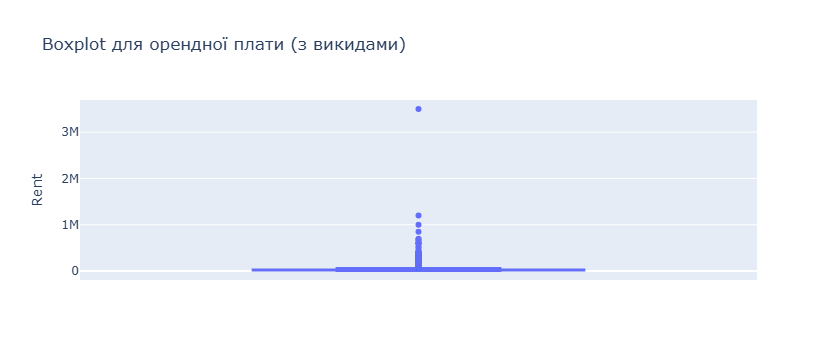

In [9]:
# Візуалізація викидів boxplot
fig = px.box(df, y="Rent", title="Boxplot для орендної плати (з викидами)")
fig.show()

In [10]:
# Робота з викидами у цільовій змінній Rent 

# 1. Розрахунок квартилів та IQR
Q1 = df["Rent"].quantile(0.25)
Q3 = df["Rent"].quantile(0.75)
IQR = Q3 - Q1

# 2. Межі для визначення викидів
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Нижня межа: {lower_bound:.2f}")
print(f"Верхня межа: {upper_bound:.2f}")

# 3. Підрахунок викидів
outliers = df[(df["Rent"] < lower_bound) | (df["Rent"] > upper_bound)]
print(f"Кількість викидів: {len(outliers)}")

# 4. Датасет без викидів
df_clean = df[(df["Rent"] >= lower_bound) & (df["Rent"] <= upper_bound)].copy()
print("Розмір датасету без викидів:", df_clean.shape)


Нижня межа: -24500.00
Верхня межа: 67500.00
Кількість викидів: 520
Розмір датасету без викидів: (4226, 12)


In [11]:
# Аналіз категоріальних змінних
# 1.  Вибираємо категоріальні колонки (тип object)
categorical_cols = df.select_dtypes(include="object").columns

# 2. Рахуємо кількість унікальних значень
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()}")

Posted On: 81
Floor: 480
Area Type: 3
Area Locality: 2235
City: 6
Furnishing Status: 3
Tenant Preferred: 3
Point of Contact: 3



## Завдання 3: Аналіз кореляцій та взаємозв'язків (3 бали)

**Що потрібно зробити:**
1. Обчисліть матрицю кореляцій для числових змінних
2. Візуалізуйте кореляційну матрицю за допомогою heatmap
3. Побудуйте scatter plot між Size та Rent
4. Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)


In [12]:
# Матриця кореляцій для числових змінних
numeric_df = df_clean[['BHK', 'Rent', 'Size', 'Bathroom']]
correlation_matrix = numeric_df.corr()

print("Матриця кореляцій:")
display(correlation_matrix)


Матриця кореляцій:


,BHK,Rent,Size,Bathroom
BHK,1.000000,0.401268,0.698453,0.747918
Rent,0.401268,1.000000,0.393605,0.506528
Size,0.698453,0.393605,1.000000,0.680607
Bathroom,0.747918,0.506528,0.680607,1.000000


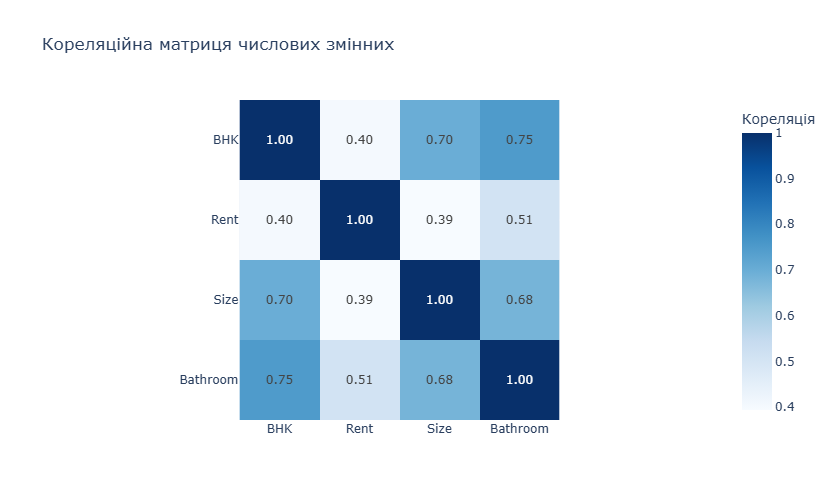

In [13]:
# Візуалізація heatmap
fig = px.imshow(
    correlation_matrix,
    text_auto='.2f',
    color_continuous_scale='Blues',
    title='Кореляційна матриця числових змінних',
    labels=dict(color="Кореляція")
)
fig.update_layout(height=500)
fig.show()

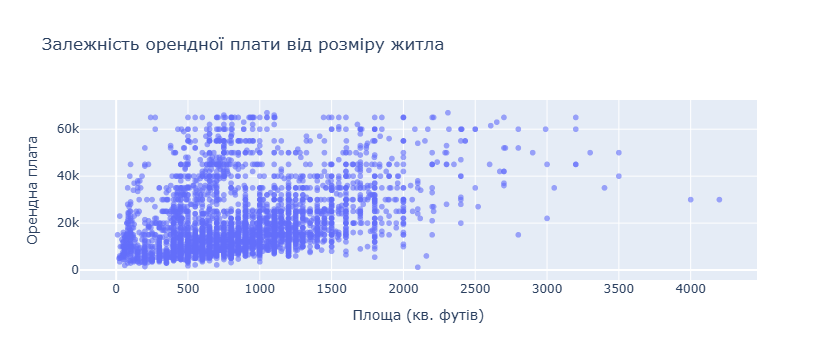

In [14]:
# scatter plot між Size та Rent
fig = px.scatter(
    df_clean,
    x="Size",
    y="Rent",
    title="Залежність орендної плати від розміру житла",
    labels={"Size": "Площа (кв. футів)", "Rent": "Орендна плата"},
    opacity=0.6
)
fig.show()

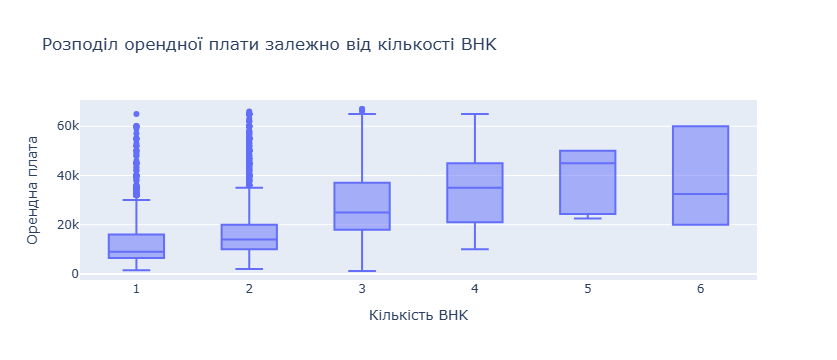

In [15]:
# Boxplot між BHK та Rent
fig = px.box(
    df_clean,
    x="BHK",
    y="Rent",
    title="Розподіл орендної плати залежно від кількості BHK",
    labels={"BHK": "Кількість BHK", "Rent": "Орендна плата"}
)
fig.show()

## Завдання 4: Feature Engineering та підготовка даних (4 бали)

**Що потрібно зробити:**
1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding. Пригадайте, що в лекції ми говорили щодо кодування кат. змінних з великої кількістю різних значень і як працювати з такими випадками. Ви можете закодувати не всі кат. змінні, а лише ті, що вважаєте за потрібні (скажімо ті, що мають відносно небагато різних значень).
2. **Опціонально (по 0.5 бала за кожну доцільну ознаку):** Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі
3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.
4. Розділіть дані на ознаки (X) та цільову змінну (y)
5. Застосуйте стандартизацію до числових ознак


In [16]:
# Кодуємо категоріальні колонки (відбираємо ті, що мають небагато унікальних значень) 
categorical_cols = ['Area Type', 'City', 'Furnishing Status', 'Tenant Preferred', "Point of Contact"]
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# Приводимо dummy-колонки до int (0/1 замість True/False)
dummy_cols = [col for col in df_encoded.columns if any(cat in col for cat in categorical_cols)]
df_encoded[dummy_cols] = df_encoded[dummy_cols].astype(int)

# Додаємо нову ознаку
df_encoded["Rent_per_sqft"] = df_encoded["Rent"] / df_encoded["Size"]

# Виключаємо колонки, які не будемо використовувати
exclude_cols = ["Rent", "Area Locality", "Posted On", "Floor"]
X = df_encoded.drop(columns=exclude_cols)
y = df_encoded["Rent"]

# Перевіряємо розміри 
print(f"Розмір X (ознаки): {X.shape}")
print(f"Розмір y (ціль): {y.shape}")

Розмір X (ознаки): (4226, 17)
Розмір y (ціль): (4226,)


In [17]:
# Стандартизуємо числові ознаки

from sklearn.preprocessing import StandardScaler

# Числові колонки для стандартизації
numeric_cols = ["BHK", "Size", "Bathroom", "Rent_per_sqft"]

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

X.head()


,BHK,Size,Bathroom,Area Type_Carpet Area,Area Type_Super Area,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Furnishing Status_Semi-Furnished,Furnishing Status_Unfurnished,Tenant Preferred_Bachelors/Family,Tenant Preferred_Family,Point of Contact_Contact Builder,Point of Contact_Contact Owner,Rent_per_sqft
0,0.052966,0.469859,0.272578,0,1,0,0,0,1,0,0,1,1,0,0,1,-0.469635
1,0.052966,-0.147778,-1.133910,0,1,0,0,0,1,0,1,0,1,0,0,1,-0.126157
2,0.052966,0.263980,-1.133910,0,1,0,0,0,1,0,1,0,1,0,0,1,-0.298878
3,0.052966,-0.147778,-1.133910,0,1,0,0,0,1,0,0,1,1,0,0,1,-0.396033
4,0.052966,-0.044839,-1.133910,1,0,0,0,0,1,0,0,1,0,0,0,1,-0.475408


## Завдання 5: Розділення даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
2. Створіть модель лінійної регресії.
3. Навчіть модель на навчальних даних.
4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
5. Зробіть прогнози на тренувальній та тестовій вибірках.

In [18]:
# Розділяємо дані: 80% train, 20% test 

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,            # ознаки стандартизовані
    y,            # ціль
    test_size=0.2,
    random_state=42
)

In [19]:
from sklearn.linear_model import LinearRegression

# Створюємо модель
model = LinearRegression()

# Навчаємо модель на навчальних даних
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
# Виводимо ваги для кожної ознаки
for feature, weight in zip(model.feature_names_in_, model.coef_):
    print(f"{feature}: {weight:.2f}")

print(f"\nЗміщення (intercept): {model.intercept_:.2f}")

BHK: 1642.61
Size: 6418.47
Bathroom: 950.87
Area Type_Carpet Area: -3100.63
Area Type_Super Area: -3521.69
City_Chennai: -924.31
City_Delhi: -752.44
City_Hyderabad: -2923.42
City_Kolkata: -2679.78
City_Mumbai: 16018.49
Furnishing Status_Semi-Furnished: -3021.92
Furnishing Status_Unfurnished: -3723.60
Tenant Preferred_Bachelors/Family: -470.36
Tenant Preferred_Family: -1805.11
Point of Contact_Contact Builder: -3692.18
Point of Contact_Contact Owner: -7864.51
Rent_per_sqft: 4520.35

Зміщення (intercept): 30926.53


Найсильніші за впливом (за абсолютним значенням коефіцієнта) → City_Mumbai (+16018) та Point of Contact_Contact Owner (-7864).  
Тобто місто і тип контакту найбільше змінюють оренду.

In [21]:
# Прогнози на навчальній вибірці
y_train_pred = model.predict(X_train)

# Прогнози на тестовій вибірці (нові дані!)
y_test_pred = model.predict(X_test)

# Порівняння перших 10 прогнозів з реальністю
comparison = pd.DataFrame({
    'Реальна оренда': y_test.values[:10],
    'Прогнозована оренда': y_test_pred[:10].round(0),
    'Помилка': (y_test.values[:10] - y_test_pred[:10]).round(0)
})
print("Приклади прогнозів на тестовій вибірці:")
print(comparison)

Приклади прогнозів на тестовій вибірці:
   Реальна оренда  Прогнозована оренда  Помилка
0           22000              28762.0  -6762.0
1            5000               2718.0   2282.0
2           37000              38728.0  -1728.0
3            8000               2381.0   5619.0
4           15000              14807.0    193.0
5           20000              20797.0   -797.0
6            8500              14403.0  -5903.0
7            7000               4155.0   2845.0
8            3000               -950.0   3950.0
9            8000               4989.0   3011.0


## Завдання 6: Оцінка якості моделі (2 бали)

**Що потрібно зробити:**
1. Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
2. Порівняйте метрики та зробіть висновок про якість моделі
3. Проаналізуйте і дайте висновок, чи є ознаки перенавчання або недонавчання (**Нагадування**: перенавчання - коли модель дуже добре працює на тренувальних даних, але погано на тестових; недонавчання - коли модель погано працює навіть на тренувальних даних)
4. Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Розраховуємо метрики для тестової вибірки
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)

print("="*50)
print("МЕТРИКИ ЯКОСТІ МОДЕЛІ (на тестовій вибірці):")
print("="*50)
print(f"\nMAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

# Порівняння з навчальною вибіркою
mae = mean_absolute_error(y_train, y_train_pred)
mse = mean_squared_error(y_train, y_train_pred)
rmse = np.sqrt(mse)
r2_train = r2_score(y_train, y_train_pred)

print("="*50)
print("МЕТРИКИ ЯКОСТІ МОДЕЛІ на тренувальній вибірці:")
print("="*50)
print(f"\nMAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2_train:.3f}")

МЕТРИКИ ЯКОСТІ МОДЕЛІ (на тестовій вибірці):

MAE: 5124.85
RMSE: 8451.13
R²: 0.628
МЕТРИКИ ЯКОСТІ МОДЕЛІ на тренувальній вибірці:

MAE: 5065.05
RMSE: 7055.23
R²: 0.739


Модель лінійної регресії показала середню похибку прогнозу близько 5 тис.  
R² на тренуванні 0.739, а на тесті 0.628. Це свідчить, що модель непогано пояснює варіацію цільової змінної, хоча точність не є ідеальною через наявність викидів і складність реальних залежностей.

Різниця між навчальною та тестовою вибірками невелика, тому ознаки перенавчання чи недонавчання відсутні.
Маємо скоріше нормальну, але не ідеальна модель, яка втрачає якість через викиди та просту лінійну форму. Загалом модель має прийнятну якість і може використовуватися для базового прогнозування.

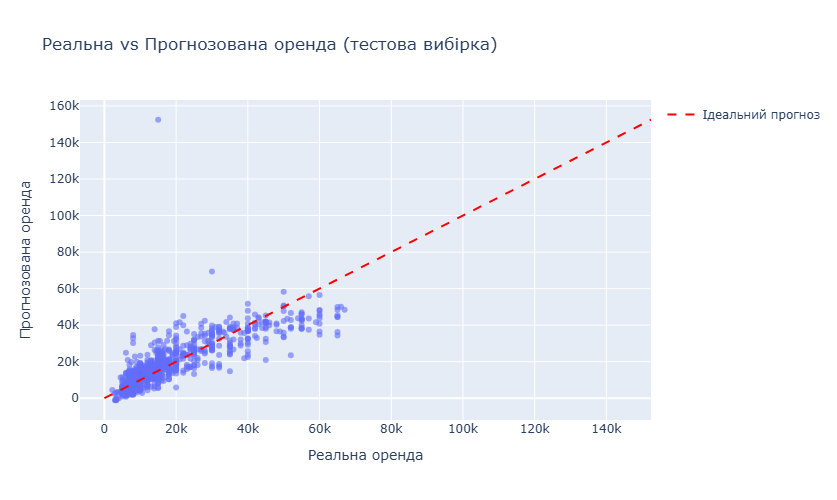

In [25]:
# Візуалізація: реальні vs прогнозовані значення
fig = px.scatter(
    x=y_test,
    y=y_test_pred,
    title='Реальна vs Прогнозована оренда (тестова вибірка)',
    labels={'x': 'Реальна оренда', 'y': 'Прогнозована оренда'},
    opacity=0.6
)

# Додаємо ідеальну лінію (де прогноз = реальність)
max_val = max(y_test.max(), y_test_pred.max())
fig.add_trace(
    go.Scatter(
        x=[0, max_val],
        y=[0, max_val],
        mode='lines',
        name='Ідеальний прогноз',
        line=dict(color='red', dash='dash')
    )
)

fig.update_layout(height=500)
fig.show()

Точки розташовані доволі близько до ідеальної червоної лінії, особливо у середньому діапазоні значень. Отже, модель добре відтворює загальну тенденцію. Також бачимо відсутність систематичного «зсуву» (усі точки вище чи нижче лінії) свідчить, що модель не має сильного перекосу.

Висновок: графік підтверджує результати метрик — модель лінійної регресії адекватно описує дані, хоча точність знижується для крайніх випадків. В цілому, прогноз є достатньо якісним для базового аналізу і демонструє збалансованість без ознак перенавчання.

## Завдання 7: Аналіз помилок (4 бали)

**Що потрібно зробити:**
1. Обчисліть помилки (residuals = реальні - прогнозовані значення)
2. Побудуйте гістограму розподілу помилок
3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?
4. Знайдіть 5 прогнозів з найбільшими помилками
5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.
6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)

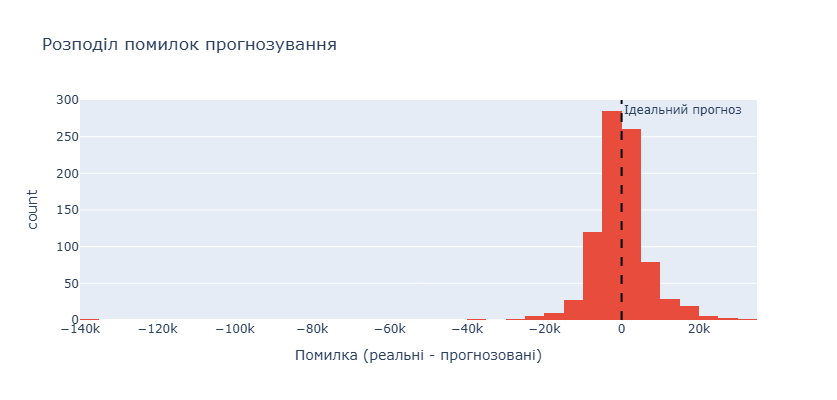

In [27]:
# Розраховуємо помилки (залишки)
residuals = y_test - y_test_pred

# Гістограма розподілу помилок
fig = px.histogram(
    x=residuals,
    nbins=50,
    title='Розподіл помилок прогнозування',
    labels={'x': 'Помилка (реальні - прогнозовані)', 'count': 'Кількість'},
    color_discrete_sequence=['#e74c3c']
)
fig.add_vline(x=0, line_dash="dash", line_color="black", annotation_text="Ідеальний прогноз")
fig.update_layout(height=400)
fig.show()

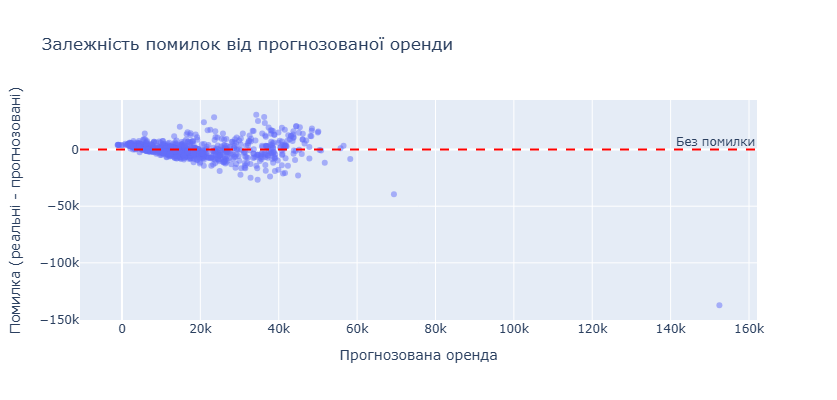

In [28]:
# Scatter plot: помилки vs прогнозовані значення
fig = px.scatter(
    x=y_test_pred,
    y=residuals,
    title='Залежність помилок від прогнозованої оренди',
    labels={'x': 'Прогнозована оренда', 'y': 'Помилка (реальні - прогнозовані)'},
    opacity=0.5
)

# Додаємо горизонтальну лінію на 0
fig.add_hline(y=0, line_dash="dash", line_color="red", annotation_text="Без помилки")

fig.update_layout(height=400)
fig.show()

In [29]:
# Знаходимо 5 прогнозів з найбільшими помилками
errors_df = pd.DataFrame({
    'Реальна оренда': y_test.values,
    'Прогнозована оренда': y_test_pred,
    'Абсолютна помилка': np.abs(residuals)
})

top_errors = errors_df.nlargest(5, 'Абсолютна помилка')
print("5 прогнозів з найбільшими помилками:")
print(top_errors)


5 прогнозів з найбільшими помилками:
      Реальна оренда  Прогнозована оренда  Абсолютна помилка
4653           15000        152446.553760      137446.553760
275            30000         69400.541860       39400.541860
3962           65000         34268.520777       30731.479223
3520           65000         36288.267541       28711.732459
2512           52000         23510.739444       28489.260556


In [31]:
# Витягуємо індекси рядків з найбільшими помилками
top_idx = top_errors.index

# Додаємо до помилок характеристики
top_errors_full = df_clean.loc[top_idx, ["City", "BHK", "Size", "Bathroom"]].join(top_errors)

print("5 прогнозів з найбільшими помилками (з характеристиками житла):")
print(top_errors_full)


5 прогнозів з найбільшими помилками (з характеристиками житла):
           City  BHK  Size  Bathroom  Реальна оренда  Прогнозована оренда  \
4653  Hyderabad    3    10         3           15000        152446.553760   
275     Kolkata    4  4000         3           30000         69400.541860   
3962  Hyderabad    3  1850         3           65000         34268.520777   
3520    Chennai    3  1444         3           65000         36288.267541   
2512      Delhi    2  1125         2           52000         23510.739444   

      Абсолютна помилка  
4653      137446.553760  
275        39400.541860  
3962       30731.479223  
3520       28711.732459  
2512       28489.260556  


**Аналіз найбільших помилок**

Модель погано справляється з:  
- екстремально малими квартирами (аномальні дані),  
- великими квартирами з високою реальною ціною,  
- дорогим сегментом квартир

**Для покращення  моделі можна зробити наступні кроки:**

Видалити або обробити викиди (наприклад, квартира з Size = 10 і орендою 15k — нетипова, модель її не може пояснити).  
Логарифмувати цільову змінну (Rent), щоб зменшити вплив дуже дорогих квартир на модель.  
Спробувати нелінійні моделі, які краще працюють із неоднорідними даними.